In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import re
import os
import numpy as np

In [2]:
# --- 1. Setup & Configuration ---
for resource in ['tokenizers/punkt', 'corpora/stopwords']:
    try: nltk.data.find(resource)
    except LookupError: 
        try: nltk.download(resource.split('/')[-1])
        except: pass

# Define Stopwords
MANUAL_STOPWORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 
    'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its', 'they', 'them', 'their', 
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 
    'than', 'too', 'very', 'can', 'will', 'just', 'don', 'should', 'now'
}
LEGAL_STOPWORDS = {
    'court', 'case', 'appeal', 'judgment', 'order', 'section', 'rule', 'act', 'code', 
    'v.', 'vs.', 'petitioner', 'respondent', 'appellant', 'appellee', 'plaintiff', 'defendant'
}
CUSTOM_STOPWORDS = { 
    'xxx'
}

try:
    FULL_STOPWORDS = set(stopwords.words('english')).union(LEGAL_STOPWORDS).union(CUSTOM_STOPWORDS)
except:
    FULL_STOPWORDS = MANUAL_STOPWORDS.union(LEGAL_STOPWORDS).union(CUSTOM_STOPWORDS)

In [3]:
# --- 2. Data Loading & Preprocessing ---
def load_data():
    # Update paths to your actual file locations
    pos_file = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    neg_file = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    
    rows = []
    LABEL_MAP = {"SUPPORT": "Support", "ATTACK": "Attack", "NO_REL": "No Relation", "NO_REL\n": "No Relation"}
    
    for fp in [pos_file, neg_file]:
        if os.path.exists(fp):
            with open(fp, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split("\t")
                    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
                    if len(fname_indices) == 2:
                        try:
                            sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
                            sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
                            label = parts[-1]
                            rows.append({"text": sent1 + " " + sent2, "label": label})
                        except: pass
    
    if not rows: return pd.DataFrame()
    df = pd.DataFrame(rows)
    df['label'] = df['label'].str.strip().map(LABEL_MAP)
    return df.dropna()

def get_ngrams_from_text(text_list, n=1):
    """
    1. Cleans text
    2. Tokenizes
    3. Generates N-grams (consecutive words)
    """
    all_ngrams = []
    for text in text_list:
        text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
        tokens = word_tokenize(text)
        # Filter tokens
        tokens = [t for t in tokens if t not in FULL_STOPWORDS and len(t) > 2]
        
        # Generate N-grams
        if len(tokens) >= n:
            grams = list(ngrams(tokens, n))
            all_ngrams.extend(grams)
            
    return all_ngrams

In [4]:
# --- 3. Analysis A: Jaccard Similarity (Overlap) ---
def calculate_jaccard_matrix(ngram_sets, labels):
    """J(A, B) = |A ∩ B|/|A ∪ B|
    0 - 20%: Very distinct vocabularies. Easy to separate.
    20 - 50%: Moderate overlap.
    > 50%: High overlap. The classes use almost the same words"""
    
    matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
    for l1 in labels:
        for l2 in labels:
            set1 = set(ngram_sets[l1])
            set2 = set(ngram_sets[l2])
            
            intersection = len(set1.intersection(set2))
            union = len(set1.union(set2))
            score = intersection / union if union > 0 else 0
            matrix.loc[l1, l2] = score
    return matrix

# --- 4. Analysis B: Probability Difference (Distinctiveness) ---
def calculate_prob_diff_scores(target_ngrams, reference_ngrams):
    """Score(w) = P(w | Target) - P(w | Reference)
    High Positive Score: The word appears frequently in the target class but rarely in others.
    Score Near Zero: The word appears equally often everywhere.
    Negative Score: The word is common in other categories but rare in this one."""
    
    target_counts = Counter(target_ngrams)
    ref_counts = Counter(reference_ngrams)
    
    total_target = sum(target_counts.values())
    total_ref = sum(ref_counts.values())
    
    if total_target == 0 or total_ref == 0: return []

    scores = {}
    for item, count in target_counts.items():
        if count < 5: continue # Filter noise
        
        prob_target = count / total_target
        prob_ref = ref_counts[item] / total_ref
        
        # Key Metric: Prob(Cluster) - Prob(Rest)
        scores[item] = prob_target - prob_ref
        
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]

Data Loaded: 40506 rows.

==================== ANALYZING UNIGRAMS (WORDS) ====================
Generating Unigrams (Words) for Support...
Generating Unigrams (Words) for Attack...
Generating Unigrams (Words) for No Relation...


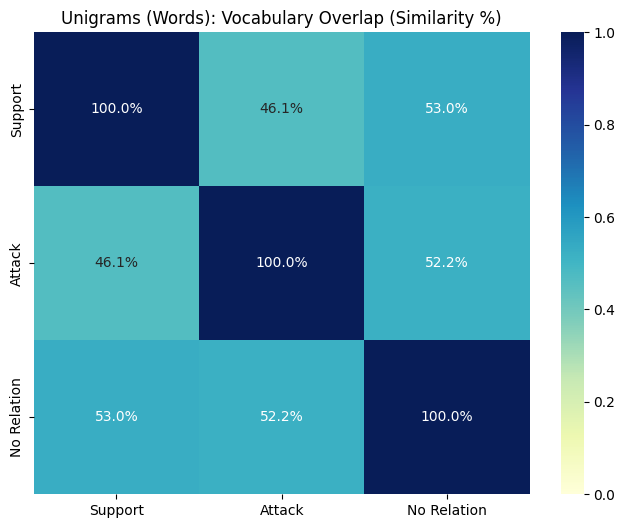

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


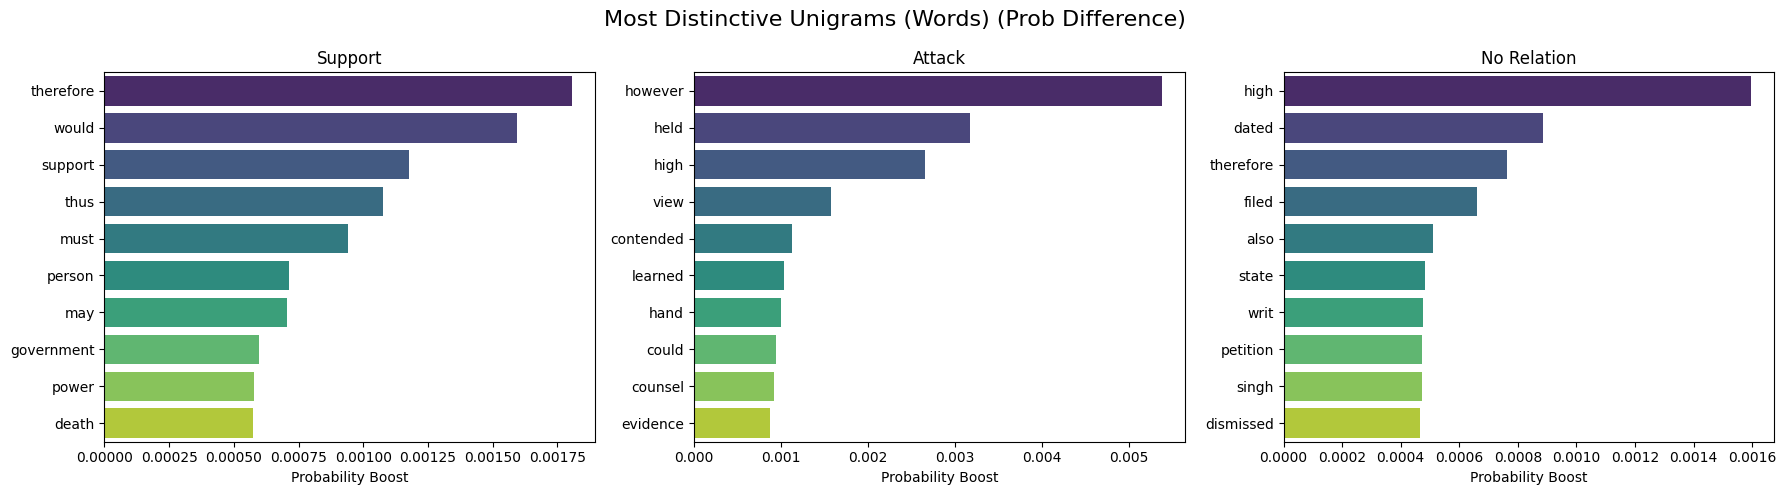


==================== ANALYZING BIGRAMS (2-WORD) ====================
Generating Bigrams (2-word) for Support...
Generating Bigrams (2-word) for Attack...
Generating Bigrams (2-word) for No Relation...


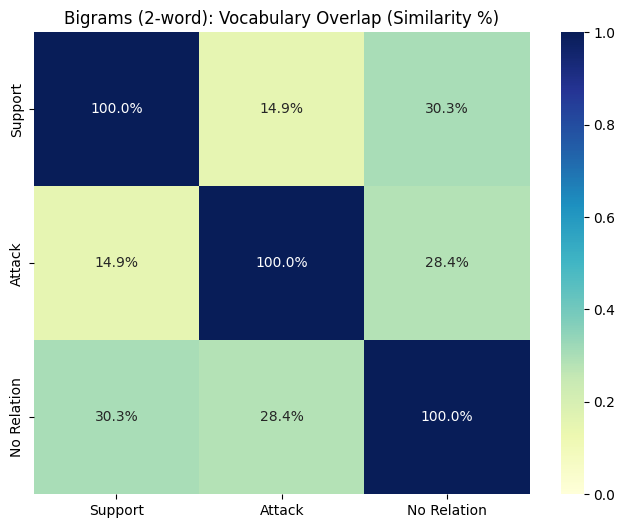

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


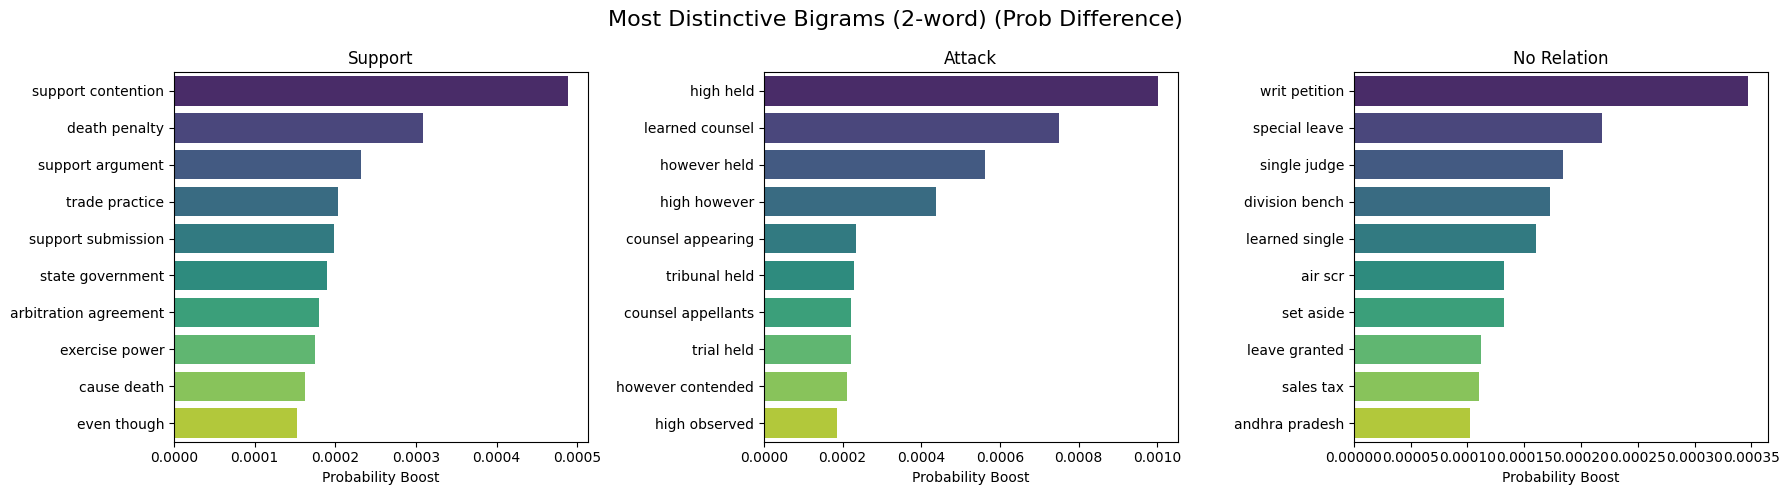


==================== ANALYZING TRIGRAMS (3-WORD) ====================
Generating Trigrams (3-word) for Support...
Generating Trigrams (3-word) for Attack...
Generating Trigrams (3-word) for No Relation...


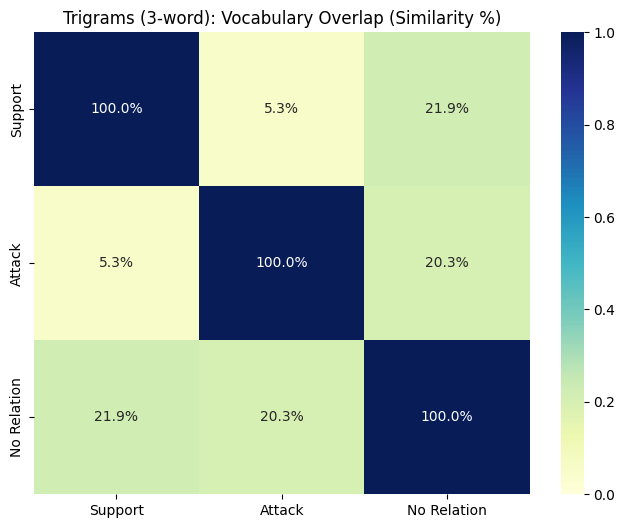

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


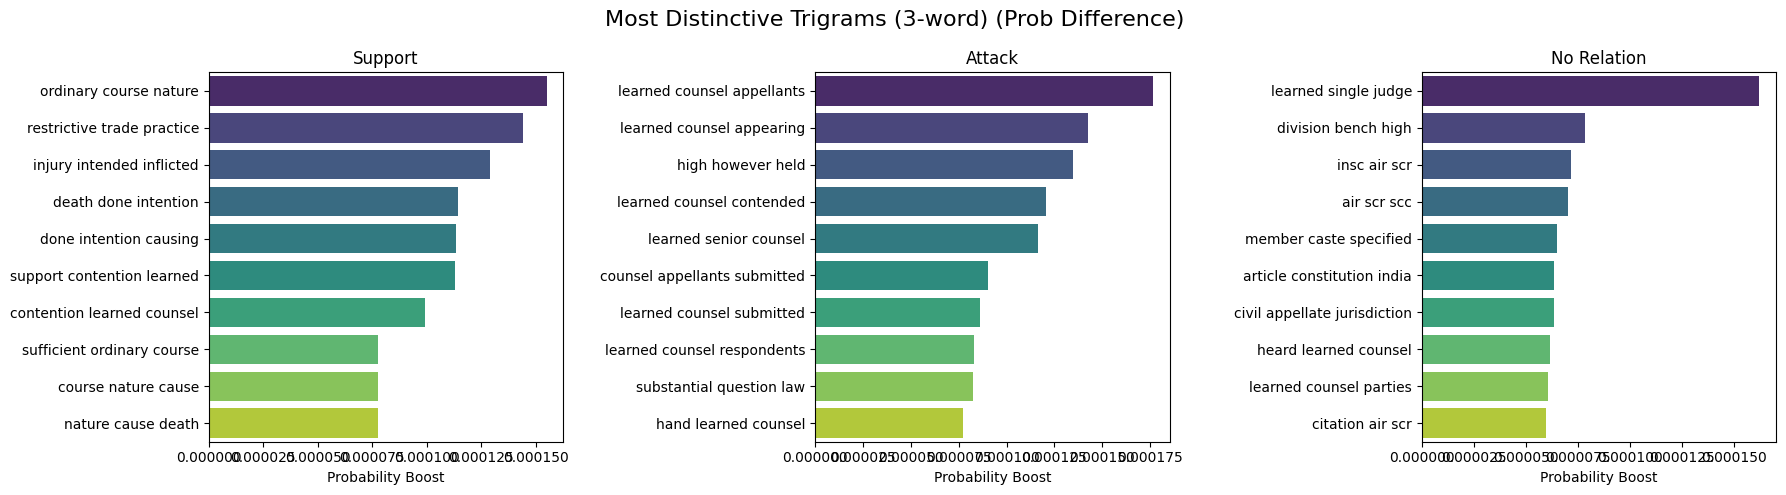

In [5]:
# --- 5. Main Execution Loop ---
if __name__ == "__main__":
    df = load_data()
    
    if not df.empty:
        print(f"Data Loaded: {len(df)} rows.")
        labels = df['label'].unique()
        
        # Prepare text pools per cluster
        cluster_texts = {label: df[df['label'] == label]['text'].tolist() for label in labels}
        
        # --- LOOP THROUGH N-GRAMS (1, 2, 3) ---
        ngram_types = {1: "Unigrams (Words)", 2: "Bigrams (2-word)", 3: "Trigrams (3-word)"}
        
        for n, name in ngram_types.items():
            print(f"\n{'='*20} ANALYZING {name.upper()} {'='*20}")
            
            # 1. Generate N-grams for each cluster
            cluster_ngrams = {}
            for label in labels:
                print(f"Generating {name} for {label}...")
                cluster_ngrams[label] = get_ngrams_from_text(cluster_texts[label], n)

            # -------------------------------------------------------
            # ANALYSIS 1: OVERLAP (Jaccard Heatmap)
            # -------------------------------------------------------
            jaccard_df = calculate_jaccard_matrix(cluster_ngrams, labels)
            
            plt.figure(figsize=(8, 6))
            # fmt='.1%' converts 0.45 to 45.0% automatically
            sns.heatmap(jaccard_df, annot=True, cmap="YlGnBu", fmt=".1%", vmin=0, vmax=1)
            plt.title(f"{name}: Vocabulary Overlap (Similarity %)")
            plt.show()

            # -------------------------------------------------------
            # ANALYSIS 2: DISTINCTIVENESS (Prob Difference)
            # -------------------------------------------------------
            diff_results = {}
            for label in labels:
                target = cluster_ngrams[label]
                # Reference = All other clusters combined
                reference = []
                for other in labels:
                    if other != label: reference.extend(cluster_ngrams[other])
                
                diff_results[label] = calculate_prob_diff_scores(target, reference)

            # Plot Distinctive Terms
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            fig.suptitle(f'Most Distinctive {name} (Prob Difference)', fontsize=16)
            
            for i, label in enumerate(labels):
                items = diff_results[label]
                if not items: continue
                
                # Format labels: ("word1", "word2") -> "word1 word2"
                tokens, scores = zip(*items)
                str_labels = [" ".join(t) if isinstance(t, tuple) else t for t in tokens]
                
                sns.barplot(x=list(scores), y=list(str_labels), ax=axes[i], palette='viridis')
                axes[i].set_title(f'{label}')
                axes[i].set_xlabel('Probability Boost')
                
            plt.tight_layout()
            plt.show()
            
    else:
        print("No data found.")